In [ ]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# 1. DATA STRUCTURE POPULATION

# Actual Road Distance g(n)
graph = {

    'Poip': {
        'Bilwas': 8,
        'Bandiwade Bk': 5,
        'Khotale': 8
    },

    'Bilwas': {
        'Mahan': 12
    },

    'Bandiwade Bk': {
        'Masure': 5
    },

    'Masure': {
        'Mahan': 6
    },

    'Mahan': {
        'Malvan': 4
    },

    'Khotale': {
        'Kasal': 8
    },

    'Kasal': {
        'Kumbharmath': 8
    },

    'Kumbharmath': {
        'Malvan': 8
    },

    'Malvan': {}
}

# Straight Line Heuristic h(n)

heuristics = {

    'Poip':26,
    'Bilwas':18,
    'Bandiwade Bk':21,
    'Masure':16,
    'Mahan':10,
    'Khotale':24,
    'Kasal':16,
    'Kumbharmath':8,
    'Malvan':0
}

# Node Coordinates

node_positions = {

    'Poip':(8,10),

    'Bilwas':(5,8),

    'Bandiwade Bk':(8,8),

    'Masure':(7,6),

    'Mahan':(5,4),

    'Khotale':(11,8),

    'Kasal':(11,6),

    'Kumbharmath':(11,4),

    'Malvan':(7,1)
}

In [ ]:

# 2. A* SEARCH ALGORITHM

def a_star_search(graph, heuristics, start, goal):

    priority_queue = [(heuristics[start], start, [start], 0)]

    visited = set()

    while priority_queue:

        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():

            if neighbor not in visited:

                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]

                heapq.heappush(
                    priority_queue,
                    (next_f, neighbor, path + [neighbor], next_g)
                )

    return None, float('inf')

# Run Algorithm

optimal_path, total_distance = a_star_search(
    graph,
    heuristics,
    'Poip',
    'Malvan'
)

print("Optimal Path Discovered:")
print(" -> ".join(optimal_path))

print("\nTotal Road Distance:", total_distance, "km")

Optimal Path Discovered:
Poip -> Bandiwade Bk -> Masure -> Mahan -> Malvan

Total Road Distance: 20 km


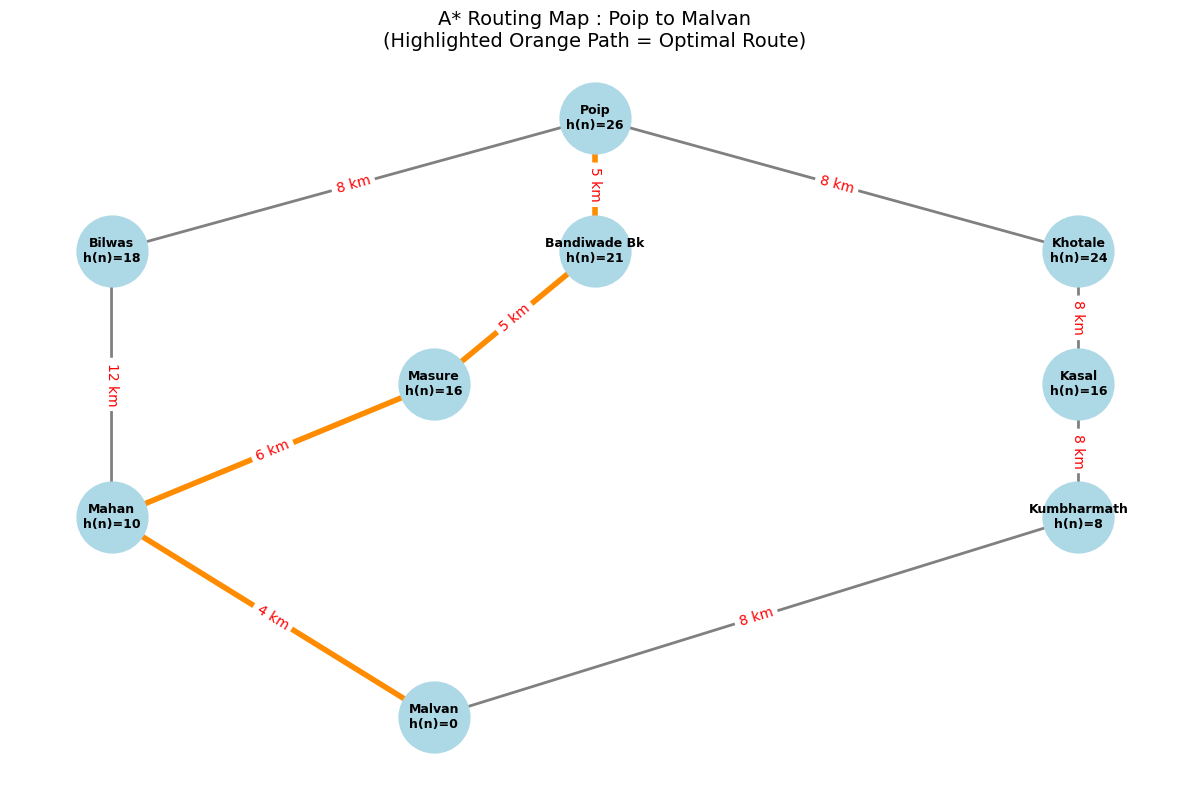

In [ ]:

# GRAPH PLOTTING

G = nx.DiGraph()

for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(12,8))

path_edges = list(zip(optimal_path, optimal_path[1:]))

normal_edges = [
    edge for edge in G.edges()
    if edge not in path_edges
]

nx.draw_networkx_nodes(
    G,
    node_positions,
    node_size=2600,
    node_color='lightblue'
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=normal_edges,
    edge_color='gray',
    width=2,
    arrows=True
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=path_edges,
    edge_color='darkorange',
    width=4,
    arrows=True
)

node_labels = {
    node:f"{node}\nh(n)={heuristics[node]}"
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    node_positions,
    labels=node_labels,
    font_size=9,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G,'weight')

formatted_edge_labels = {
    k:f"{v} km"
    for k,v in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    G,
    node_positions,
    edge_labels=formatted_edge_labels,
    font_color='red'
)

plt.title(
    "A* Routing Map : Poip to Malvan\n(Highlighted Orange Path = Optimal Route)",
    fontsize=14
)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
# 1. NETWORK DEFINITION
# Road distances g(n)
graph = {

    'Poip': {
        'Bilwas': 8,
        'Bandiwade Bk': 5,
        'Khotale': 8
    },
    'Bilwas': {
        'Mahan': 12
    },
    'Bandiwade Bk': {
        'Masure': 5
    },
    'Masure': {
        'Mahan': 6
    },
    'Mahan': {
        'Malvan': 4
    },
    'Khotale': {
        'Kasal': 8
    },
    'Kasal': {
        'Kumbharmath': 8
    },
    'Kumbharmath': {
        'Malvan': 8
    },
    'Malvan': {}
}
# Straight-line heuristic values h(n)
heuristics = {
    'Poip':26,
    'Bilwas':18,
    'Bandiwade Bk':21,
    'Masure':16,
    'Mahan':10,
    'Khotale':24,
    'Kasal':16,
    'Kumbharmath':8,
    'Malvan':0
}
# Coordinates only for plotting
coords = {
    'Poip':(5,9),
    'Bilwas':(2,7),
    'Bandiwade Bk':(5,7),
    'Khotale':(8,7),
    'Mahan':(2,4),
    'Masure':(5,4),
    'Kasal':(8,4),
    'Kumbharmath':(8,2),
    'Malvan':(4,1)
}



In [ ]:
# 2. RECURSIVE BEST FIRST SEARCH (RBFS)
def rbfs_search(start, goal):
    success, path, cost, _ = rbfs(
        start,
        goal,
        g=0,
        f_limit=float('inf'),
        path=[start]
    )
    return path, cost
def rbfs(node, goal, g, f_limit, path):
    if node == goal:
        return True, path, g, g
    neighbors = graph[node]
    if not neighbors:
        return False, [], 0, float('inf')
    successors=[]
    for neighbor,distance in neighbors.items():
        if neighbor not in path:
            next_g=g+distance
            next_f=max(
                next_g+heuristics[neighbor],
                g+heuristics[node]
            )
            successors.append([next_f,neighbor,next_g])
    if not successors:
        return False,[],0,float('inf')
    while True:
        successors.sort(key=lambda x:x[0])
        best=successors[0]
        if best[0]>f_limit:
            return False,[],0,best[0]
        alternative=successors[1][0] if len(successors)>1 else float('inf')
        success,result_path,total_g,returned_f=rbfs(
            best[1],
            goal,
            best[2],
            min(f_limit,alternative),
            path+[best[1]]
        )
        best[0]=returned_f
        if success:
            return True,result_path,total_g,returned_f
# RUN RBFS
path,total_dist=rbfs_search("Poip","Malvan")
print("Optimal RBFS Path:")
print(" -> ".join(path))
print("\nTotal Distance:",total_dist,"km")

Optimal RBFS Path:
Poip -> Bandiwade Bk -> Masure -> Mahan -> Malvan

Total Distance: 20 km


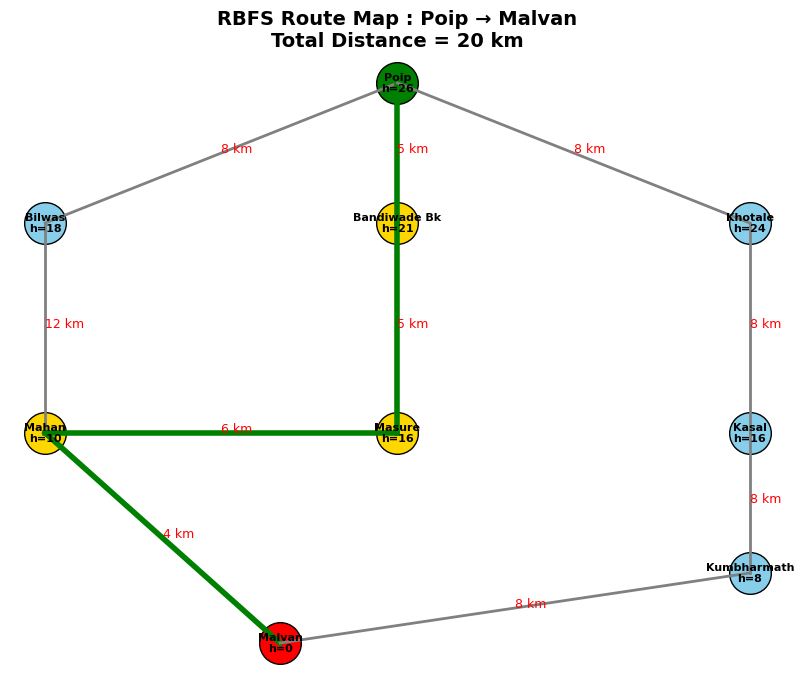

In [ ]:
# GRAPH PLOTTING

plt.figure(figsize=(10,8))

for node,neighbors in graph.items():
    x1,y1=coords[node]
    for neighbor,dist in neighbors.items():
        x2,y2=coords[neighbor]
        is_path=(
            node in path and
            neighbor in path and
            path.index(neighbor)==path.index(node)+1
        )
        color,width=("green",4) if is_path else ("gray",2)
        plt.plot(
            [x1,x2],
            [y1,y2],
            color=color,
            linewidth=width
        )
        plt.text(
            (x1+x2)/2,
            (y1+y2)/2,
            f"{dist} km",
            color="red",
            fontsize=9
        )
for node,(x,y) in coords.items():
    if node=="Poip":
        color="green"

    elif node=="Malvan":
        color="red"
    elif node in path:
        color="gold"
    else:
        color="skyblue"
    plt.scatter(
        x,
        y,
        s=900,
        color=color,
        edgecolors="black"
    )
    plt.text(
        x,
        y,
        f"{node}\nh={heuristics[node]}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold"
    )
plt.title(
    f"RBFS Route Map : Poip → Malvan\nTotal Distance = {total_dist} km",
    fontsize=14,
    fontweight="bold"
)
plt.axis("off")
plt.show()